In [26]:
import pandas as pd

dvla = pd.read_csv("df_VEH0160_UK.csv", encoding="latin1")
print(dvla.head())
print(dvla.columns.tolist())


  BodyType    Make    GenModel                 Model    Fuel  2025 Q3  \
0     Cars  ABARTH  ABARTH 124       124 GT MULTIAIR  PETROL        0   
1     Cars  ABARTH  ABARTH 124  124 GT MULTIAIR AUTO  PETROL        0   
2     Cars  ABARTH  ABARTH 500                   500  PETROL        2   
3     Cars  ABARTH  ABARTH 500                 500 C  PETROL        0   
4     Cars  ABARTH  ABARTH 500            500 CUSTOM  PETROL        0   

   2025 Q2  2025 Q1  2024 Q4  2024 Q3  2024 Q2  2024 Q1  2023 Q4  2023 Q3  \
0        0        0        0        0        0        0        0        0   
1        0        0        0        0        0        0        0        0   
2        0        2        0        0        0        0        0        0   
3        0        0        0        0        0        0        0        0   
4        0        0        0        0        0        0        0        0   

   2023 Q2  2023 Q1  2022 Q4  2022 Q3  2022 Q2  2022 Q1  2021 Q4  2021 Q3  \
0        0        0  

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option("display.max_columns", 100)

dvla = pd.read_csv("df_VEH0160_UK.csv", encoding="latin1")

# Keep only cars
dvla_cars = dvla[dvla["BodyType"] == "Cars"].copy()

print("DVLA cars shape:", dvla_cars.shape)
print(dvla_cars.head())


DVLA cars shape: (32832, 50)
  BodyType    Make    GenModel                 Model    Fuel  2025 Q3  \
0     Cars  ABARTH  ABARTH 124       124 GT MULTIAIR  PETROL        0   
1     Cars  ABARTH  ABARTH 124  124 GT MULTIAIR AUTO  PETROL        0   
2     Cars  ABARTH  ABARTH 500                   500  PETROL        2   
3     Cars  ABARTH  ABARTH 500                 500 C  PETROL        0   
4     Cars  ABARTH  ABARTH 500            500 CUSTOM  PETROL        0   

   2025 Q2  2025 Q1  2024 Q4  2024 Q3  2024 Q2  2024 Q1  2023 Q4  2023 Q3  \
0        0        0        0        0        0        0        0        0   
1        0        0        0        0        0        0        0        0   
2        0        2        0        0        0        0        0        0   
3        0        0        0        0        0        0        0        0   
4        0        0        0        0        0        0        0        0   

   2023 Q2  2023 Q1  2022 Q4  2022 Q3  2022 Q2  2022 Q1  2021 Q4  202

In [11]:
# List of quarter columns (all except first 5 descriptive cols)
quarter_cols = dvla_cars.columns[5:]

# Melt to long format: one row per fuel–quarter
dvla_long = dvla_cars.melt(
    id_vars=["BodyType", "Fuel"],
    value_vars=quarter_cols,
    var_name="Quarter",
    value_name="Registrations"
)

# Aggregate: total registrations per Fuel and Quarter
dvla_agg = (
    dvla_long
    .groupby(["Fuel", "Quarter"], as_index=False)["Registrations"]
    .sum()
)

print(dvla_agg.head())


               Fuel  Quarter  Registrations
0  BATTERY ELECTRIC  2014 Q3           1980
1  BATTERY ELECTRIC  2014 Q4           2228
2  BATTERY ELECTRIC  2015 Q1           2693
3  BATTERY ELECTRIC  2015 Q2           2083
4  BATTERY ELECTRIC  2015 Q3           2303


In [12]:
# Convert "2025 Q3" style to datetime index
def quarter_to_period(q_str):
    year, q = q_str.split()
    month = {"Q1": 1, "Q2": 4, "Q3": 7, "Q4": 10}[q]
    return pd.Timestamp(int(year), month, 1)

dvla_agg["Date"] = dvla_agg["Quarter"].apply(quarter_to_period)

# Pivot: rows = Date, cols = Fuel type, values = Registrations
fuel_table = dvla_agg.pivot_table(
    index="Date",
    columns="Fuel",
    values="Registrations",
    aggfunc="sum"
).sort_index()

fuel_table = fuel_table.apply(pd.to_numeric, errors="coerce")

print("Fuel table shape:", fuel_table.shape)
print(fuel_table.head())


Fuel table shape: (45, 11)
Fuel        BATTERY ELECTRIC  DIESEL  FUEL CELL ELECTRIC  GAS  \
Date                                                            
2014-07-01              1980  333866                   3   12   
2014-10-01              2228  267091                   3    9   
2015-01-01              2693  351192                   1    8   
2015-04-01              2083  317150                   0   11   
2015-07-01              2303  340792                   5   15   

Fuel        HYBRID ELECTRIC (DIESEL)  HYBRID ELECTRIC (PETROL)  \
Date                                                             
2014-07-01                       692                      9094   
2014-10-01                       660                      7492   
2015-01-01                      1075                     11036   
2015-04-01                      1240                      9820   
2015-07-01                      1026                     11041   

Fuel        OTHER FUEL TYPES  PETROL  PLUG-IN HYBRID E

In [13]:
main_fuels = fuel_table.columns.tolist()  # or manually subset if too many

# For plots, take a few key fuels if list is long:
plot_fuels = main_fuels[:4]  # first 4, adjust as needed


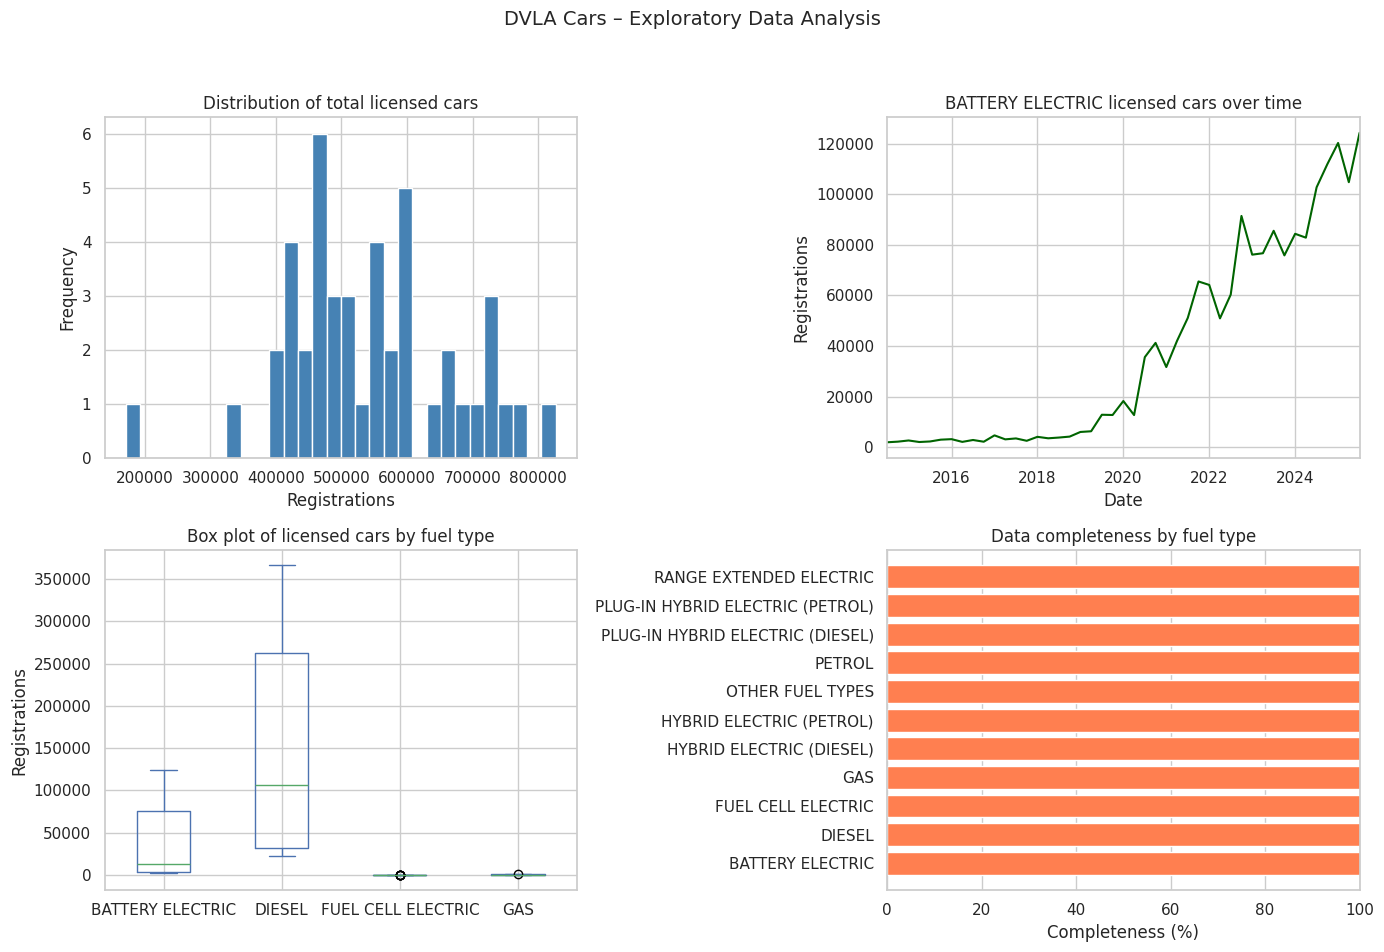

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("DVLA Cars – Exploratory Data Analysis", fontsize=14)

# 1) Histogram of total across fuels (sum over fuels at each date)
fuel_total = fuel_table.sum(axis=1)
fuel_total.hist(bins=30, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Distribution of total licensed cars")
axes[0, 0].set_xlabel("Registrations")
axes[0, 0].set_ylabel("Frequency")

# 2) Time series plot for a key fuel (e.g. PETROL)
fuel_table[plot_fuels[0]].plot(ax=axes[0, 1], label=plot_fuels[0], color="darkgreen")
axes[0, 1].set_title(f"{plot_fuels[0]} licensed cars over time")
axes[0, 1].set_xlabel("Date")
axes[0, 1].set_ylabel("Registrations")

# 3) Box plot across selected fuels
fuel_table[plot_fuels].plot(kind="box", ax=axes[1, 0])
axes[1, 0].set_title("Box plot of licensed cars by fuel type")
axes[1, 0].set_ylabel("Registrations")

# 4) Data completeness
completeness = fuel_table[main_fuels].notna().mean() * 100
axes[1, 1].barh(main_fuels, completeness, color="coral")
axes[1, 1].set_xlim(0, 100)
axes[1, 1].set_title("Data completeness by fuel type")
axes[1, 1].set_xlabel("Completeness (%)")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


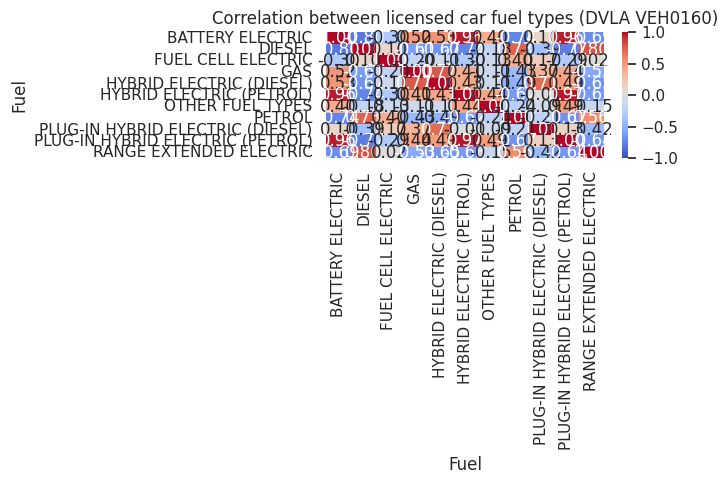

In [15]:
corr_dvla = fuel_table.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_dvla,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("Correlation between licensed car fuel types (DVLA VEH0160)")
plt.tight_layout()
plt.show()


In [16]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Choose key fuel types (adjust to what you see in fuel_table.columns)
all_fuels = fuel_table.columns.tolist()
print(all_fuels)


['BATTERY ELECTRIC', 'DIESEL', 'FUEL CELL ELECTRIC', 'GAS', 'HYBRID ELECTRIC (DIESEL)', 'HYBRID ELECTRIC (PETROL)', 'OTHER FUEL TYPES', 'PETROL', 'PLUG-IN HYBRID ELECTRIC (DIESEL)', 'PLUG-IN HYBRID ELECTRIC (PETROL)', 'RANGE EXTENDED ELECTRIC']


In [18]:
main_fuels = [
    "PETROL",
    "DIESEL",
    "HYBRID ELECTRIC (PETROL)",
    "BATTERY ELECTRIC",
    "PLUG-IN HYBRID ELECTRIC (PETROL)"
]


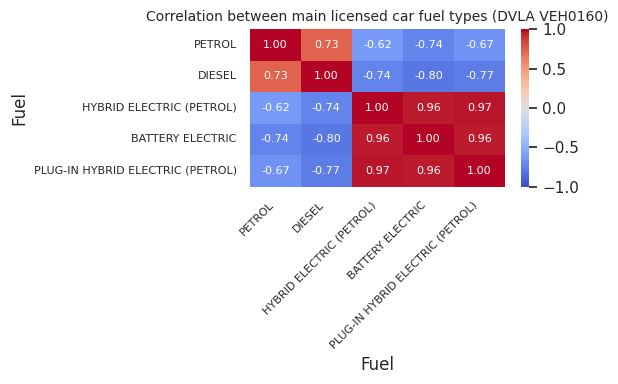

In [19]:
corr_main = fuel_table[main_fuels].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(
    corr_main,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annot_kws={"size": 8}
)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title("Correlation between main licensed car fuel types (DVLA VEH0160)", fontsize=10)
plt.tight_layout()
plt.show()


In [20]:
from sklearn.model_selection import train_test_split

# Use main_fuels list from heatmap
X = fuel_table[main_fuels].copy()
y = fuel_table[main_fuels].sum(axis=1)   # total licensed cars across those fuels

# Drop rows with NaNs
data = pd.concat([X, y.rename("Total")], axis=1).dropna()
X = data[main_fuels]
y = data["Total"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(X_train.shape, X_test.shape)


(36, 5) (9, 5)


In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lr = lin_reg.predict(X_test)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = math.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression MAE:", mae_lr)
print("Linear Regression RMSE:", rmse_lr)


Linear Regression MAE: 5.820766091346741e-11
Linear Regression RMSE: 6.995690201610927e-11


In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(random_state=42)

param_dist = {
    "n_estimators": [100, 200, 500],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]

}

rf_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)
print("Best RF params:", rf_search.best_params_)

rf_best = rf_search.best_estimator_

y_pred_rf = rf_best.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = math.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)


Best RF params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 5}
Random Forest MAE: 141381.7897116402
Random Forest RMSE: 152002.21863874714


In [24]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 1D total series
total_series = y.values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
total_scaled = scaler.fit_transform(total_series)

def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback, 0])
        y.append(data[i+lookback, 0])
    return np.array(X), np.array(y)

lookback = 8   # past 8 quarters
X_seq, y_seq = create_sequences(total_scaled, lookback)

# train/test split on sequences
split = int(len(X_seq) * 0.8)
X_train_l, X_test_l = X_seq[:split], X_seq[split:]
y_train_l, y_test_l = y_seq[:split], y_seq[split:]

X_train_l = X_train_l.reshape((X_train_l.shape[0], X_train_l.shape[1], 1))
X_test_l  = X_test_l.reshape((X_test_l.shape[0],  X_test_l.shape[1],  1))

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(lookback, 1)),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")

es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = model.fit(
    X_train_l, y_train_l,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[es],
    verbose=0
)

y_pred_l_scaled = model.predict(X_test_l, verbose=0)
y_test_l_inv = scaler.inverse_transform(y_test_l.reshape(-1, 1)).ravel()
y_pred_l_inv = scaler.inverse_transform(y_pred_l_scaled).ravel()

mae_lstm  = mean_absolute_error(y_test_l_inv, y_pred_l_inv)
rmse_lstm = math.sqrt(mean_squared_error(y_test_l_inv, y_pred_l_inv))

print("LSTM MAE:", mae_lstm)
print("LSTM RMSE:", rmse_lstm)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM MAE: 40232.40234375
LSTM RMSE: 48716.32772416851


In [25]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "LSTM"],
    "MAE":  [mae_lr, mae_rf, mae_lstm],
    "RMSE": [rmse_lr, rmse_rf, rmse_lstm]
})

print(results)


               Model           MAE          RMSE
0  Linear Regression  5.820766e-11  6.995690e-11
1      Random Forest  1.413818e+05  1.520022e+05
2               LSTM  4.023240e+04  4.871633e+04
